## K-Means Clustering
K-Means does 3 things:

- Pick K random centroids

- Assign points to nearest centroid

- Recompute centroids

- Repeat until convergence

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

warnings.filterwarnings("ignore")

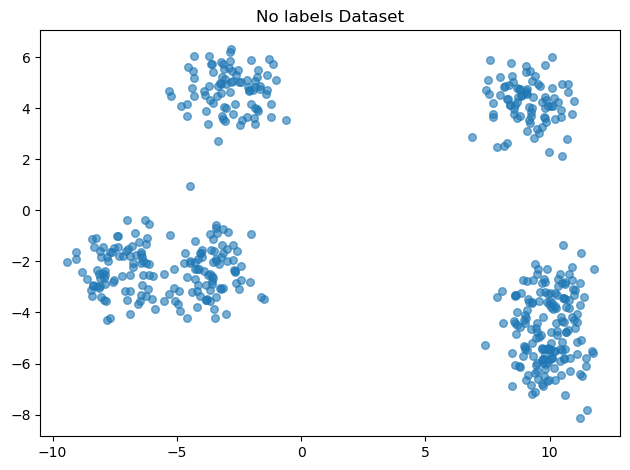

In [109]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, y_true = make_blobs(n_samples=500, centers=6, cluster_std=0.9, random_state=24)

plt.Figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=30, alpha=0.6)
plt.title('No labels Dataset')
plt.tight_layout()
plt.show()

In [25]:
""" 
 A       B       C
128     12      1000
834     31      887
958     75      500
711     82      433
222     99      110
881     101     254
"""

' \n128     12      1000\n834     31      887\n958     75      500\n711     82      433\n222     99      110\n881     101     254\n'

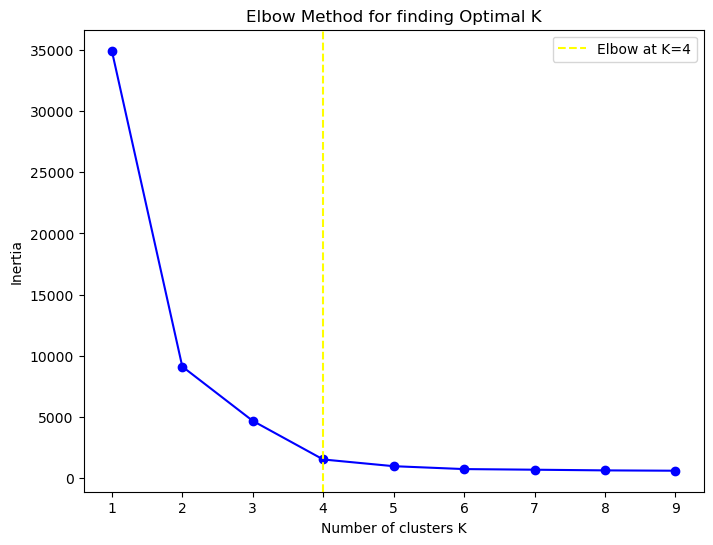

In [110]:
#elbow plot
inertia = []
k_range = range(1, 10)

for k in k_range: 
    km = KMeans(n_clusters=k, random_state=24)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method for finding Optimal K')
plt.axvline(x=4, color='yellow', linestyle='--', label='Elbow at K=4')
plt.legend()
plt.show()

In [29]:
inertia

[34925.5756902768,
 9124.063993109874,
 4688.675936439533,
 1535.0214079209748,
 986.7875300605631,
 750.0942544732328,
 698.9539109897196,
 643.9516682276746,
 616.1834975969618]

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


km_final = KMeans(n_clusters=5, random_state=24)
labels = km_final.fit_predict(X_scaled)


In [111]:
X_scaled

array([[ 0.84370444,  0.21190952,  0.37639185,  1.12815215],
       [ 1.71592374,  0.26610633, -0.0741693 , -0.88640526],
       [ 0.17276652, -0.95332186, -1.07926723,  1.12815215],
       [-0.76654658, -1.44109314, -1.59914547, -0.88640526],
       [ 1.11207961, -0.00487771, -0.52473044, -0.88640526],
       [-1.23620312, -0.68233782,  0.4803675 ,  1.12815215],
       [-0.36398382,  0.94356644, -0.03951075, -0.88640526],
       [ 0.84370444, -0.30296016, -1.14858433,  1.12815215],
       [-0.49817141,  1.18745208, -0.21280349,  1.12815215],
       [-0.22979624, -0.49264899,  1.45080688, -0.88640526],
       [-1.03492175, -1.03461708, -0.69802319, -0.88640526],
       [-1.03492175,  0.45579516,  1.48546543,  1.12815215],
       [-0.16270245, -0.08617293, -0.14348639, -0.88640526],
       [ 0.64242306,  1.51263293, -1.52982837, -0.88640526],
       [ 0.91079823, -0.81782984,  1.69341673, -0.88640526],
       [-0.16270245,  0.91646803, -0.45541334,  1.12815215],
       [-1.57167208,  0.

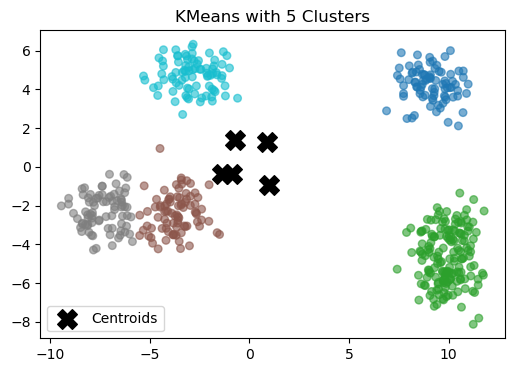

In [113]:
plt.figure(figsize=(6, 4))
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=30, alpha=0.6)
plt.scatter(
    km_final.cluster_centers_[:, 0],
    km_final.cluster_centers_[:,  1],
    s=200, c='black', marker='X', label="Centroids"
)
plt.title('KMeans with 5 Clusters')
plt.legend()
plt.show()

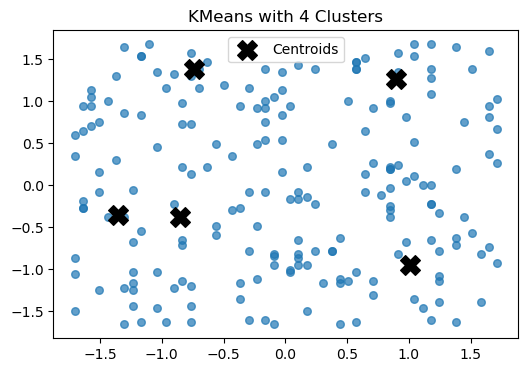

In [115]:
plt.figure(figsize=(6, 4))
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], cmap='tab10', s=30, alpha=0.7)
plt.scatter(
    km_final.cluster_centers_[:, 0],
    km_final.cluster_centers_[:,  1],
    s=200, c='black', marker='X', label="Centroids"
)
plt.title('KMeans with 4 Clusters')
plt.legend()
plt.show()

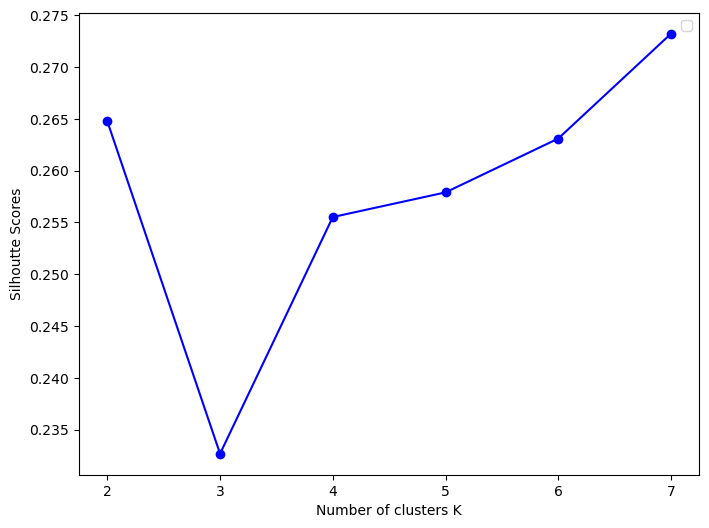

In [117]:
from sklearn.metrics import silhouette_score


scores = []

k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=24, n_init='auto')
    kmeans.fit(X_scaled)
    scores.append(silhouette_score(X_scaled, kmeans.labels_))



plt.figure(figsize=(8, 6))
plt.plot(k_range,scores, 'bo-')
plt.xlabel('Number of clusters K')
plt.ylabel('Silhoutte Scores')
# plt.axvline(x=11, color='yellow', linestyle='--', label='Elbow at K=11')
plt.legend()

In [36]:
#loading our dataset
df =pd.read_csv('./mall_customers.csv', index_col='Unnamed: 0')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Age            200 non-null    int64 
 1   AnnualIncome   200 non-null    int64 
 2   SpendingScore  200 non-null    int64 
 3   Genre          200 non-null    object
dtypes: int64(3), object(1)
memory usage: 7.8+ KB


In [37]:
df.head()

,Age,AnnualIncome,SpendingScore,Genre
0,56,84,61,Female
1,69,86,48,Male
2,46,41,19,Female
3,32,23,4,Male
4,60,76,35,Male


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Age            200 non-null    int64 
 1   AnnualIncome   200 non-null    int64 
 2   SpendingScore  200 non-null    int64 
 3   Genre          200 non-null    object
dtypes: int64(3), object(1)
memory usage: 7.8+ KB


In [54]:
df['Genre'].unique()

array(['Female', 'Male'], dtype=object)

In [55]:
df['Genre'] = df['Genre'].map({'Male':0, "Female":1})

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            200 non-null    int64
 1   AnnualIncome   200 non-null    int64
 2   SpendingScore  200 non-null    int64
 3   Genre          200 non-null    int64
dtypes: int64(4)
memory usage: 7.8 KB


In [83]:
# X = df[['Age', 'AnnualIncome', 'SpendingScore']]
X = df

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



We need to find the optimal K.

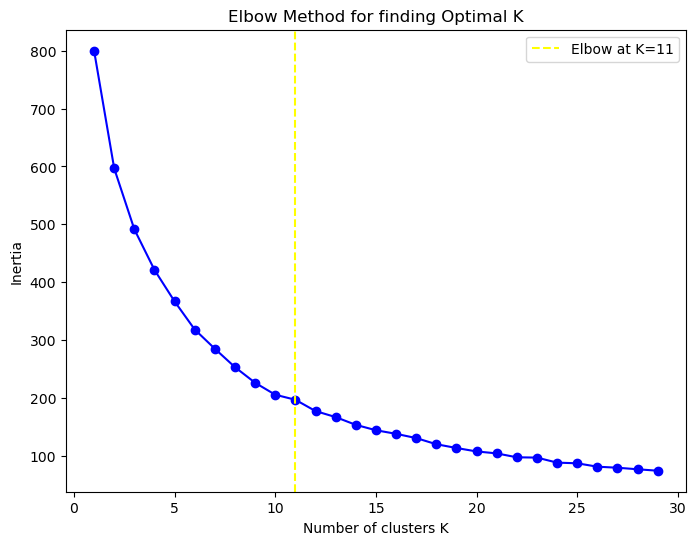

In [121]:
inertia = []

k_range = range(1, 30)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=24, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method for finding Optimal K')
plt.axvline(x=11, color='yellow', linestyle='--', label='Elbow at K=11')
plt.legend()
plt.show()

In [66]:
df_copy = df.copy()

In [96]:
#with 11 as our chosen optimal k we can proceed.
kmeans = KMeans(n_clusters=11, random_state=24, n_init=10)
df_copy['cluster'] = kmeans.fit_predict(X_scaled)

kmeans.labels_
# df_copy['cluster'].head(10)

array([ 5,  7,  8,  1,  7,  0,  9, 10,  3,  2,  1,  0,  1,  7,  4,  3,  8,
        6,  8,  3,  5,  3,  5,  2,  2,  4,  8,  5,  7,  3,  7,  1,  6,  5,
        3,  2,  4,  7,  7, 10,  0,  7,  7,  8,  8,  2,  1,  1,  8,  8,  8,
        4,  6,  3,  8,  6,  5, 10,  1, 10,  2,  7,  7,  9,  9,  7,  4, 10,
        1,  9,  0,  3,  8,  6,  0,  6,  4,  4,  9,  5,  8,  1,  7,  2,  0,
        1,  9,  5,  0,  9,  5,  8,  4,  8,  9,  5,  4,  7,  1,  3,  7,  0,
        1,  6,  0,  9,  2,  3,  2,  9,  9,  7,  3,  8,  7,  5,  1,  0,  4,
        7,  4,  4,  9,  9,  8,  9, 10,  4, 10,  3,  5,  4,  4, 10,  7,  5,
        4,  3,  0,  7,  5,  4,  0,  8,  9,  9,  6,  3,  7,  5,  0,  2,  9,
        3,  5,  2,  4,  7,  4,  4, 10,  5,  8,  8,  4,  1,  1,  5,  3,  4,
        4, 10,  8,  4,  2, 10,  2,  7,  9, 10,  5,  8,  5,  8,  3,  3,  1,
        1,  2,  1,  1,  7,  4,  8,  3,  1,  9,  5,  9,  7])

In [79]:
#profile our data
cluster_profile = df_copy.groupby('cluster').mean()

print(cluster_profile)

               Age  AnnualIncome  SpendingScore  Genre
cluster                                               
0        25.769231     72.461538      81.230769    1.0
1        41.700000     47.100000      23.450000    0.0
2        29.142857     43.500000      73.142857    0.0
3        43.842105    117.052632      59.578947    1.0
4        56.720000     38.520000      72.000000    0.0
5        51.428571     54.095238      71.761905    1.0
6        39.625000    107.625000      90.000000    0.0
7        58.440000    106.680000      27.400000    0.0
8        29.173913     62.782609      27.347826    1.0
9        29.750000    115.300000      40.500000    0.0
10       61.083333     95.166667      16.333333    1.0


In [ ]:
""" 
- Variance ratio
- Calinski-harabasz
- Silhoutte score
"""

## Challenges of Clustering
1. **Choosing K (K-Means)**
The elbow method is solid, however, its not a guarantee. Silhoutte scores give you a second opinion.
2. Sensitivity to scale
3. Sensitivity to Ouliers
4. ***
5. Dimensionality--- Before any clustering happens always apply PCA(dimensionality reduction)

In [100]:
inertia

[800.0,
 596.5906766831365,
 491.42738985391173,
 421.2799073256427,
 366.8461155288959,
 318.29566958396765,
 285.069443483139,
 253.26635265882808,
 226.2944345595975,
 205.66041001377567,
 196.96454197791357,
 177.4385841846567,
 167.02821247158775,
 153.64248415267195,
 144.3081932899719,
 138.11195732238113,
 130.79295798110746]

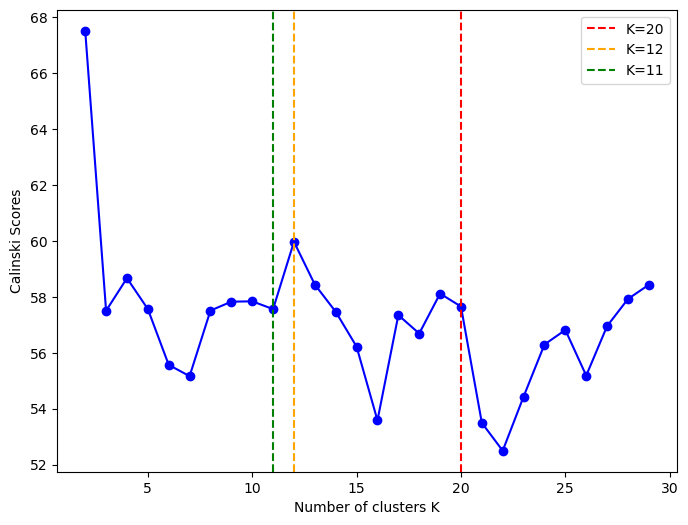

In [130]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score


scores = []

k_range = range(2, 30)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=24, n_init='auto')
    kmeans.fit(X_scaled)
    scores.append(calinski_harabasz_score(X_scaled, kmeans.labels_))



plt.figure(figsize=(8, 6))
plt.plot(k_range,scores, 'bo-')
plt.xlabel('Number of clusters K')
plt.ylabel('Calinski Scores')
plt.axvline(x=20, color='red', linestyle='--', label='K=20')
plt.axvline(x=12, color='orange', linestyle='--', label='K=12')
plt.axvline(x=11, color='green', linestyle='--', label='K=11')
plt.legend()

In [128]:
kmeans = KMeans(n_clusters=2, random_state=24, n_init='auto')
kmeans.fit(X_scaled)

calinski_harabasz_score(X_scaled, kmeans.labels_)

67.50867486004971

In [131]:
# plt.figure(figsize=(6, 4))
# plt.plot(k_range, scores, 'bo-')   # FIXED: use scores instead of inertia
# plt.xlabel('Number of clusters K')
# plt.ylabel('Silhouette Score')
# plt.title('Silhouette Method for Finding Optimal K')
# plt.show()

In [ ]:
KMeans(n_clusters=k, random_state=24, n_init='auto')
kmeans.fit(X_scaled)
scores.append(silhouette_score(X_scaled, kmeans.labels_))

array([12, 13,  9,  7, 13,  1, 16, 14,  4, 10,  7,  1,  7,  6,  8,  4,  4,
       16,  9,  4, 12, 11, 12, 10, 10,  8,  9, 15,  6, 11,  6,  7,  8, 12,
        4, 10,  0,  6, 13,  3,  1,  6, 13,  9,  9, 10, 13,  7,  4,  9,  4,
       13, 16,  4,  9, 10, 12,  3,  7, 14, 10, 13, 16,  2, 16,  6,  0,  3,
        7,  2,  1, 11,  9,  8,  1, 16,  0,  8, 16, 12,  9,  7, 13, 16,  9,
        7, 16, 12, 15, 16,  5,  9,  8,  4, 16, 15,  8,  6,  0,  4, 13,  1,
        7, 16,  1, 16, 10,  3,  7, 16,  2,  6,  4,  9,  6,  5,  7,  1,  0,
       13,  8,  8, 16,  2,  9,  2,  3,  0, 14,  4, 15,  0,  8, 14,  6, 15,
        0, 11,  1,  6, 12,  0,  1,  4,  2,  2, 16,  4,  6, 15,  1, 10, 16,
       11, 12, 10,  8,  6,  8,  8,  3, 15,  4,  9,  8,  7, 13,  5,  4,  0,
        8, 14,  9,  0, 10, 14, 10,  6,  2,  3,  5,  4, 15,  9, 11, 11,  7,
        7,  7,  7,  7,  6,  0,  9,  4, 13, 16, 12,  2, 13])

In [ ]:
""" 
monthly_airtime_top_up     |      monthly_total_spend      |    monthly_okoa_jahazi
 1000                               700                             0
 200                                500                             300
 500                                650                             150
"""

### Semi-Supervised & Look-Alike Models.

### PCA
Principal Component Analysis reduces high-dimensional data into **principal components** that capture the maximum variation in the dataset.

#### Uses of PCA
- Visualization ( 3D/2D)
- Noise reduction
- Preprocessing for clustering


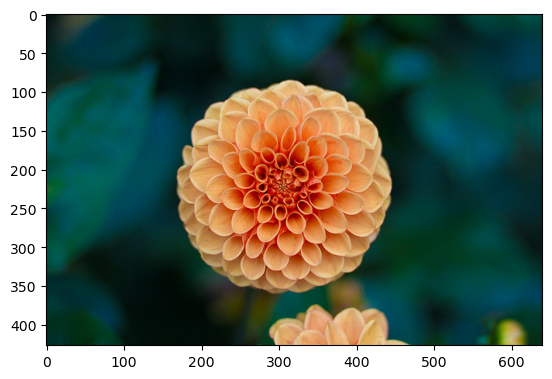

In [148]:
""" 
rgb

(255, 255, 255)
"""

from sklearn.datasets import load_sample_image, load_digits


X = load_digits().data
# y = load_digits().target

# plt.imshow(X[1].reshape(8, 8), cmap='gray')
X.shape

flower = load_sample_image('flower.jpg')

plt.imshow(flower)


In [149]:
X.shape

(1797, 64)

In [146]:
flower.shape

(427, 640, 3)

In [152]:
427 * 640

273280

Reshaping converts this into a 2D matrix.

In [153]:
h, w, c = flower.shape

flower_reshaped = flower.reshape(-1, 3)

flower_reshaped.shape

(273280, 3)

In [156]:
from sklearn.decomposition import PCA


#apply pca on flower
pca_flower = PCA(n_components=2)

flower_reduced = pca_flower.fit_transform(flower_reshaped)

flower_reduced.shape

(273280, 2)

In [ ]:
flower_reduced

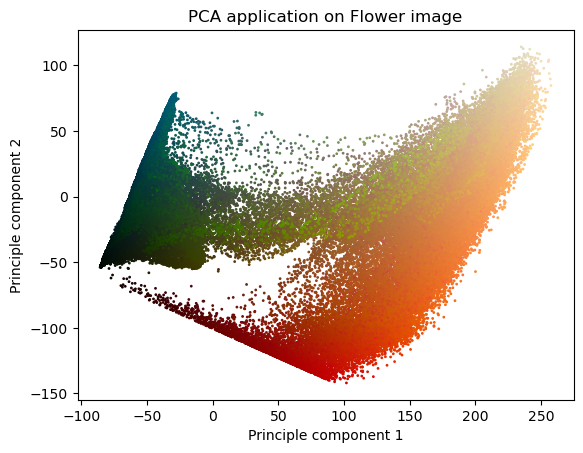

In [158]:
plt.scatter(
    flower_reduced[:,0],
    flower_reduced[:,1],
    c=flower_reshaped/255,
    s=1
)

plt.xlabel('Principle component 1')
plt.ylabel('Principle component 2')
plt.title("PCA application on Flower image")
plt.show()

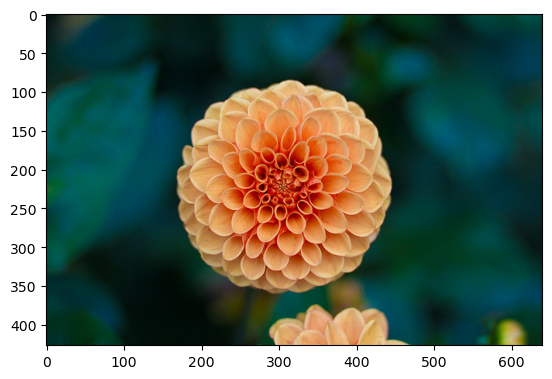

In [159]:
plt.imshow(flower)

In [160]:
pca_flower.explained_variance_ratio_

array([0.86312145, 0.12910953])

In [164]:
reconstructed_flower = pca_flower.inverse_transform(flower_reduced)

image = reconstructed_flower.reshape(h, w, 3)

image.shape

(427, 640, 3)

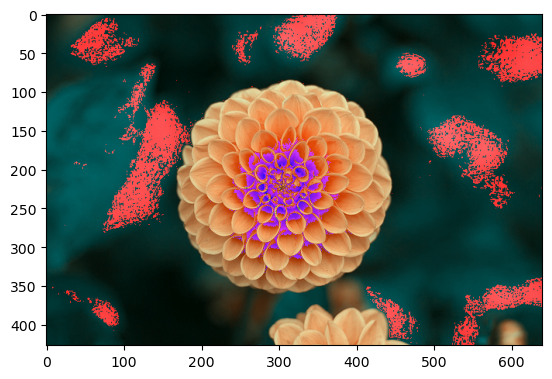

In [166]:
plt.imshow(image.astype(np.uint8))